# Customer Segmentation pada E-Commerce Menggunakan RFM Analysis dan K-Means Clustering

## Project Overview

Project ini bertujuan untuk melakukan segmentasi customer berdasarkan perilaku transaksi menggunakan RFM Analysis dan K-Means Clustering.

RFM Analysis digunakan untuk mengukur:
- Recency: seberapa baru customer melakukan transaksi
- Frequency: seberapa sering customer melakukan transaksi
- Monetary: seberapa besar nilai transaksi customer

Hasil segmentasi kemudian dianalisis untuk menghasilkan insight dan rekomendasi strategi bisnis.

## Business Problem

Perusahaan memiliki banyak customer dengan karakteristik transaksi yang berbeda.

Customer yang sering bertransaksi dan memiliki nilai transaksi tinggi membutuhkan strategi yang berbeda dibandingkan customer yang sudah lama tidak melakukan transaksi.

Oleh karena itu, project ini bertujuan untuk menjawab:

> Bagaimana cara mengelompokkan customer berdasarkan perilaku transaksi sehingga perusahaan dapat menerapkan strategi pemasaran yang lebih tepat?

# 1. Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 2. Data Understanding

## Load Dataset

In [2]:
df = pd.read_excel("../Dataset/Online_Retail.xlsx")
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,"17,850.00",United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,"17,850.00",United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,"13,047.00",United Kingdom


In [3]:
print(f"Jumlah Baris : {df.shape[0]:,}")
print(f"Jumlah Kolom : {df.shape[1]}")

Jumlah Baris : 541,909
Jumlah Kolom : 8


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


### Initial Observation

Dataset berisi informasi transaksi seperti invoice, produk, quantity, tanggal transaksi, harga, customer, dan negara. `CustomerID` menjadi atribut penting karena segmentasi dilakukan pada level customer.

# 3. Data Quality Check

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df[df.isnull().any(axis=1)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df[df.duplicated(keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,"17,908.00",United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,"17,908.00",United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,"17,908.00",United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,"17,908.00",United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,"17,908.00",United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,"14,446.00",United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,"14,446.00",United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,"14,446.00",United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,"14,446.00",United Kingdom


In [10]:
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,"14,527.00",United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom


In [11]:
df[df['UnitPrice'] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom




Pemeriksaan awal menunjukkan adanya missing value pada `CustomerID` dan `Description`, duplicate rows, serta nilai `Quantity` dan `UnitPrice` yang tidak valid untuk analisis pembelian normal.

Karena segmentasi dilakukan pada level customer, transaksi tanpa `CustomerID` tidak dapat digunakan. Transaksi dengan `Quantity <= 0` atau `UnitPrice <= 0` juga tidak digunakan.

**Catatan:** duplicate rows ditemukan pada dataset. Pada analisis ini duplicate tidak langsung diasumsikan sebagai error bisnis; treatment duplicate perlu disesuaikan dengan definisi transaksi pada sumber data. Hasil model di bawah mempertahankan metodologi asli project agar hasil dapat direproduksi.

# 4. Data Cleaning

In [12]:
df_clean = df.copy()
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

In [13]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [14]:
df_clean.shape

(397884, 8)

In [15]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
df_clean.duplicated().sum()

np.int64(5192)

In [17]:
df_clean.drop_duplicates(inplace=True)

In [18]:
print(f"Jumlah data sebelum cleaning : {len(df):,}")
print(f"Jumlah data setelah cleaning : {len(df_clean):,}")
print(f"Data yang dihapus            : {len(df) - len(df_clean):,}")

Jumlah data sebelum cleaning : 541,909
Jumlah data setelah cleaning : 392,692
Data yang dihapus            : 149,217


In [19]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom




Setelah cleaning, dataset hanya berisi transaksi dengan customer yang teridentifikasi serta quantity dan harga yang valid.

# 5. Features Engenering

Revenue dihitung sebagai:

**Revenue = Quantity × UnitPrice**

In [20]:
df_clean['Revenue'] = (
    df_clean['Quantity'] *
    df_clean['UnitPrice']
)

# 6. RFM Analysis

RFM digunakan untuk mengubah data transaksi menjadi karakteristik customer.

### Recency
Jumlah hari sejak transaksi terakhir customer.

Semakin kecil nilai Recency, semakin baru customer melakukan transaksi.

### Frequency
Jumlah transaksi unik yang dilakukan customer.

Semakin tinggi Frequency, semakin sering customer bertransaksi.

### Monetary
Total revenue yang dihasilkan customer.

Semakin tinggi Monetary, semakin besar kontribusi customer terhadap bisnis.

In [21]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


In [22]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (
        reference_date - x.max()
    ).days,

    'InvoiceNo': 'nunique',

    'Revenue': 'sum'
})

In [23]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
"12,346.00",326,1,"77,183.60"
"12,347.00",2,7,"4,310.00"
"12,348.00",75,4,"1,797.24"
"12,349.00",19,1,"1,757.55"
"12,350.00",310,1,334.40


In [24]:
rfm.describe()

,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
max,374.00,209.00,"280,206.02"


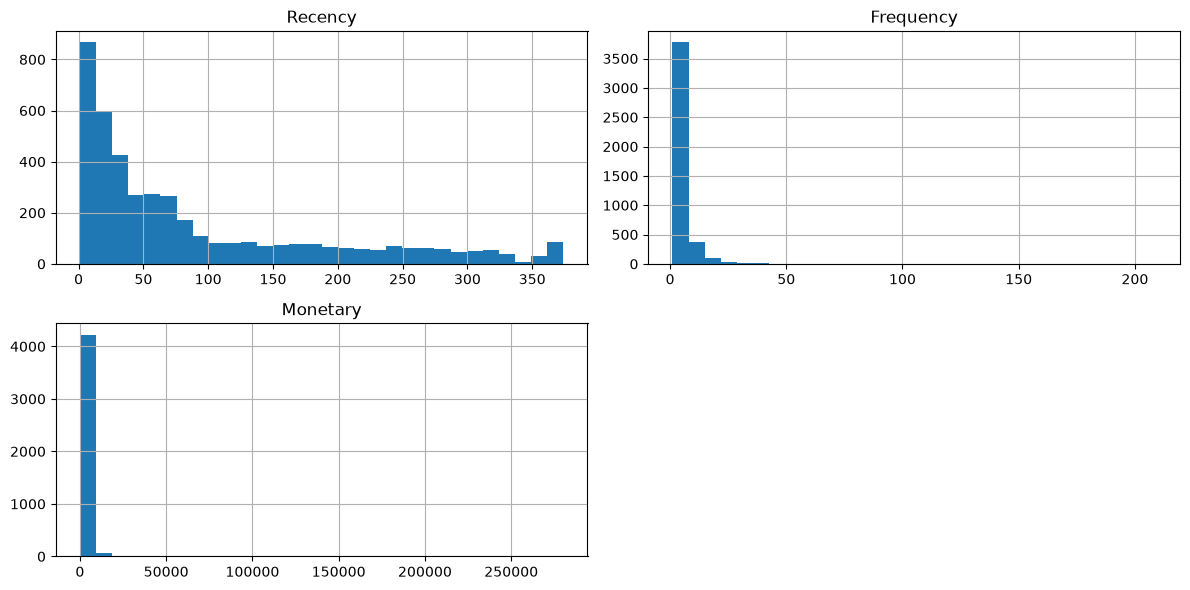

In [25]:

rfm.hist(
    figsize=(12, 6),
    bins=30
)

plt.tight_layout()
plt.savefig("../output/figure/rfm.png")
plt.show()


Distribusi RFM menunjukkan adanya skewness, terutama pada Frequency dan Monetary. Beberapa customer memiliki nilai transaksi dan jumlah transaksi jauh lebih tinggi dibandingkan mayoritas customer.

# 7. RFM Preprocessing

## Log Transformation

Karena RFM memiliki distribusi yang skewed, `log1p()` digunakan untuk mengurangi pengaruh nilai ekstrem tanpa menghilangkan customer bernilai tinggi.

In [26]:

rfm_log = np.log1p(rfm)

In [27]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,3.83,1.35,6.59
std,1.34,0.68,1.26
min,0.69,0.69,1.56
25%,2.94,0.69,5.73
50%,3.95,1.10,6.51
75%,4.96,1.79,7.42
max,5.93,5.35,12.54


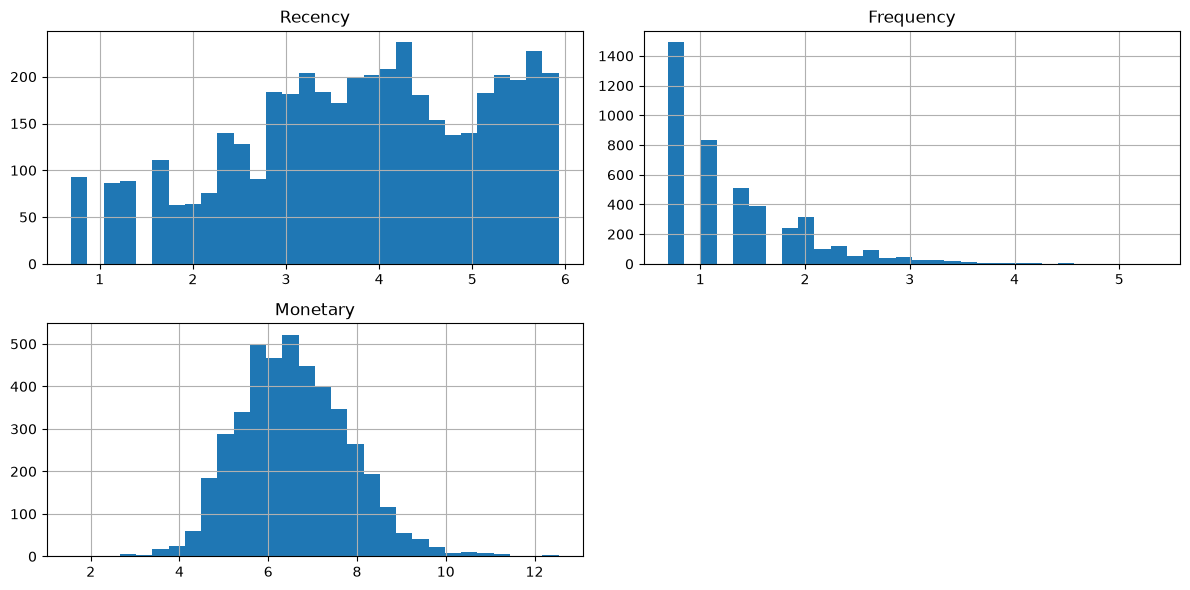

In [28]:
import matplotlib.pyplot as plt

rfm_log.hist(
    figsize=(12, 6),
    bins=30
)

plt.tight_layout()
plt.savefig("../output/figure/rfm_log.png")
plt.show()

## Feature Scaling

StandardScaler digunakan agar ketiga fitur berada pada skala yang comparable sebelum digunakan oleh K-Means.

In [29]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [30]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=rfm.columns
)

In [31]:
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
"12,346.00",1.46,-0.96,3.71
"12,347.00",-2.04,1.07,1.41
"12,348.00",0.37,0.39,0.72
"12,349.00",-0.62,-0.96,0.70
"12,350.00",1.42,-0.96,-0.61


# 8. Determine Optimal Number of Clusters

Dua pendekatan digunakan:

1. **Elbow Method** untuk melihat perubahan inertia ketika jumlah cluster bertambah.
2. **Silhouette Score** untuk mengevaluasi kualitas pemisahan cluster.

In [32]:

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

In [33]:
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}, Inertia = {value:.2f}")

K = 2, Inertia = 6483.59
K = 3, Inertia = 4869.49
K = 4, Inertia = 3939.05
K = 5, Inertia = 3296.71
K = 6, Inertia = 2855.76
K = 7, Inertia = 2548.82
K = 8, Inertia = 2336.34
K = 9, Inertia = 2156.01
K = 10, Inertia = 2005.75


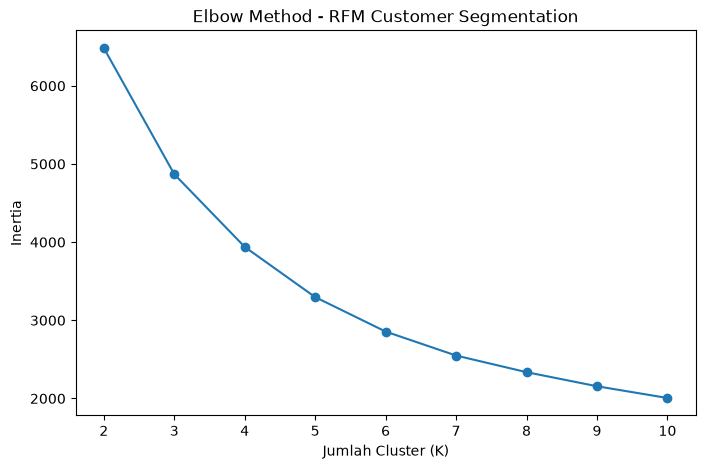

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - RFM Customer Segmentation')
plt.savefig("../output/figure/elbow_method.png")
plt.show()

In [35]:

silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(
        rfm_scaled,
        labels
    )
    
    silhouette_scores.append(score)

In [36]:
for k, score in zip(
    range(2, 11),
    silhouette_scores
):
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.433
K = 3, Silhouette Score = 0.337
K = 4, Silhouette Score = 0.338
K = 5, Silhouette Score = 0.316
K = 6, Silhouette Score = 0.312
K = 7, Silhouette Score = 0.309
K = 8, Silhouette Score = 0.303
K = 9, Silhouette Score = 0.281
K = 10, Silhouette Score = 0.277


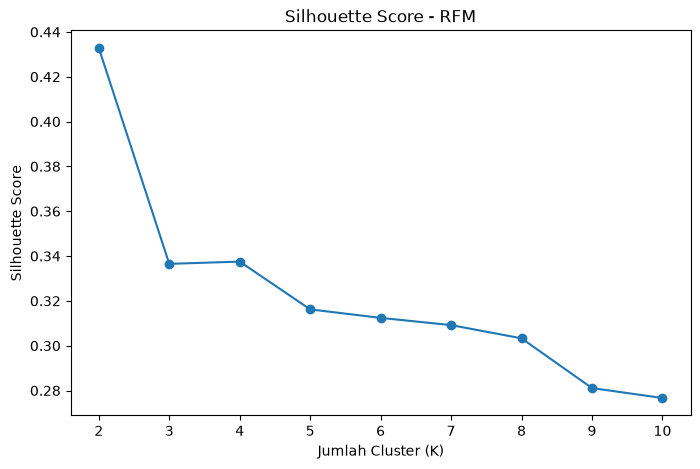

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - RFM')
plt.savefig("../output/figure/silhouette.png")
plt.show()

### Model Selection

Pada hasil analisis ini, **K = 2** memberikan Silhouette Score tertinggi, yaitu sekitar **0.433**. Elbow Method juga menunjukkan bahwa penurunan inertia semakin berkurang ketika jumlah cluster ditambah.

Dengan mempertimbangkan kedua evaluasi tersebut, digunakan **2 cluster** untuk segmentasi final.

# 9. K-Means Customer Segmentation

In [38]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'].value_counts().sort_index()

Cluster
0    2672
1    1666
Name: count, dtype: int64

## Cluster Profiling

K-Means hanya menghasilkan label numerik. Nama segment diberikan setelah karakteristik RFM setiap cluster dianalisis.

In [39]:
cluster_profile = rfm.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Customer_Count=('Cluster', 'count')
)

cluster_profile.round(2)

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,134.09,1.67,495.59,2672
1,25.89,8.44,"4,539.60",1666


In [40]:
cluster_median = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].median()

cluster_median.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,96.00,1.00,363.08
1,16.00,6.00,"2,061.08"


### Cluster Interpretation

- Cluster dengan **Recency lebih tinggi, Frequency lebih rendah, dan Monetary lebih rendah** diinterpretasikan sebagai **Low Value / Inactive**.
- Cluster dengan **Recency lebih rendah, Frequency lebih tinggi, dan Monetary lebih tinggi** diinterpretasikan sebagai **High Value / Active**.

Interpretasi ini dilakukan setelah melihat profil cluster; K-Means sendiri tidak mengetahui arti bisnis dari nomor cluster.

In [41]:
cluster_labels = {
    0: 'Low Value / Inactive',
    1: 'High Value / Active'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm[['Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
"12,346.00",326,1,"77,183.60",1,High Value / Active
"12,347.00",2,7,"4,310.00",1,High Value / Active
"12,348.00",75,4,"1,797.24",1,High Value / Active
"12,349.00",19,1,"1,757.55",0,Low Value / Inactive
"12,350.00",310,1,334.40,0,Low Value / Inactive


# 10. Segment Summary

In [42]:
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('Segment', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Monetary=('Monetary', 'sum')
)

segment_summary['Customer_Percentage'] = (
    segment_summary['Customer_Count'] / len(rfm) * 100
)

segment_summary['Revenue_Percentage'] = (
    segment_summary['Total_Monetary'] /
    segment_summary['Total_Monetary'].sum() * 100
)

segment_summary.round(2)

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Customer_Percentage,Revenue_Percentage
Segment,,,,,,,
High Value / Active,1666,25.89,8.44,"4,539.60","7,562,979.20",38.40,85.10
Low Value / Inactive,2672,134.09,1.67,495.59,"1,324,229.69",61.60,14.90


## Customer Distribution vs Revenue Contribution

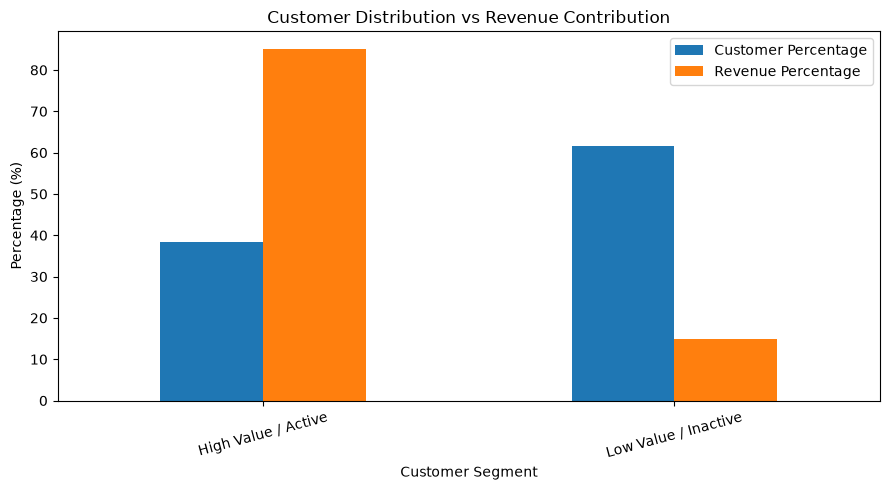

In [43]:
comparison = segment_summary[
    ['Customer_Percentage', 'Revenue_Percentage']
]

ax = comparison.plot(kind='bar', figsize=(9, 5))
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Customer Segment')
ax.set_title('Customer Distribution vs Revenue Contribution')
plt.xticks(rotation=15)
plt.legend(['Customer Percentage', 'Revenue Percentage'])
plt.tight_layout()
plt.savefig("../output/figure/customer_ditribution_vs_Reveneu_Contributin.png")
plt.show()

# 11. PCA Visualization

PCA digunakan **hanya untuk visualisasi** hasil clustering dalam dua dimensi. PCA bukan bagian dari proses pembentukan cluster final.

In [44]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm_pca_df = pd.DataFrame(
    rfm_pca,
    columns=['PC1', 'PC2'],
    index=rfm.index
)
rfm_pca_df['Cluster'] = rfm['Cluster']

explained_variance = pca.explained_variance_ratio_
print('Explained variance ratio:', explained_variance)
print(f'Total explained variance: {explained_variance.sum():.3f}')

Explained variance ratio: [0.75078634 0.18786648]
Total explained variance: 0.939


In [45]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=['Recency', 'Frequency', 'Monetary']
)

loadings.round(3)

,PC1,PC2
Recency,-0.51,0.85
Frequency,0.62,0.26
Monetary,0.60,0.46


c:\Users\LENOVO\OneDrive\Documents\Ecomerce-linear-regression\env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


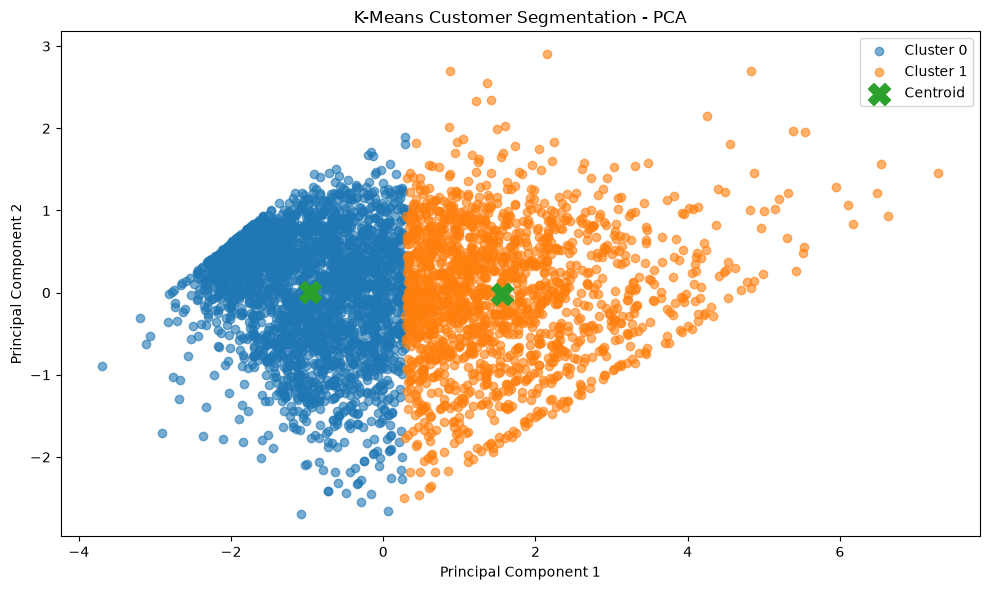

In [46]:
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))

for cluster in sorted(rfm_pca_df['Cluster'].unique()):
    cluster_data = rfm_pca_df[rfm_pca_df['Cluster'] == cluster]
    
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=250,
    label='Centroid'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Customer Segmentation - PCA')
plt.legend()
plt.tight_layout()
plt.savefig("../output/figure/K-Means_Customer.png")
plt.show()

### PCA Interpretation

Dua principal component menjelaskan sekitar **93.9%** variasi pada data RFM setelah preprocessing. Visualisasi PCA digunakan untuk melihat pemisahan relatif antar-cluster, sedangkan kualitas cluster tetap dievaluasi menggunakan Silhouette Score.

# 12. Business Insight

Berdasarkan hasil segmentasi:

### High Value / Active

- Customer lebih baru melakukan transaksi (Recency rendah).
- Frekuensi transaksi lebih tinggi.
- Nilai transaksi rata-rata jauh lebih tinggi.
- Terdiri dari sekitar **38.43% customer**.
- Memberikan sekitar **85.08% kontribusi Monetary**.

### Low Value / Inactive

- Sudah lebih lama sejak transaksi terakhir (Recency tinggi).
- Frekuensi transaksi lebih rendah.
- Nilai transaksi rata-rata lebih rendah.
- Terdiri dari sekitar **61.57% customer**.
- Memberikan sekitar **14.92% kontribusi Monetary**.

Temuan utama adalah adanya perbedaan yang cukup besar antara ukuran customer dan kontribusi Monetary pada kedua segmen.

In [47]:
ratio = (
    segment_summary.loc['High Value / Active', 'Avg_Monetary'] /
    segment_summary.loc['Low Value / Inactive', 'Avg_Monetary']
)

print(f'Rasio Average Monetary: {ratio:.2f}x')

Rasio Average Monetary: 9.16x


# 13. Business Recommendation

## High Value / Active

Strategi yang dapat dipertimbangkan:

- Loyalty program atau VIP membership.
- Exclusive offers dan early access.
- Personalized product recommendation.
- Cross-selling dan upselling.
- Retention campaign.

**Tujuan:** mempertahankan customer bernilai tinggi dan mendorong pembelian berulang.

## Low Value / Inactive

Strategi yang dapat dipertimbangkan:

- Re-engagement campaign.
- Personalized discount atau voucher.
- Product recommendation.
- Email marketing.
- Bundling atau promotional campaign.

**Tujuan:** meningkatkan kembali aktivitas customer, terutama Frequency dan Monetary.

# 14. Limitations

Beberapa keterbatasan analisis ini:

- Segmentasi hanya menggunakan tiga variabel RFM.
- Periode analisis mengikuti periode yang tersedia pada dataset.
- K-Means memiliki asumsi bentuk cluster tertentu dan sensitif terhadap representasi fitur.
- Dua cluster menghasilkan segmentasi yang cukup general dan mungkin belum menangkap sub-segment customer yang lebih spesifik.
- Hasil segmentasi perlu divalidasi dengan konteks bisnis dan data aktual sebelum diterapkan sebagai kebijakan pemasaran.

# 15. Conclusion

K-Means Clustering berhasil digunakan untuk melakukan customer segmentation berdasarkan **Recency, Frequency, dan Monetary**.

Berdasarkan Elbow Method dan Silhouette Score, **K = 2** digunakan untuk model final dengan Silhouette Score sekitar **0.433**.

Hasil clustering menghasilkan dua segmen utama:

1. **High Value / Active** — customer lebih aktif dengan Frequency dan Monetary yang lebih tinggi.
2. **Low Value / Inactive** — customer dengan Recency lebih tinggi serta Frequency dan Monetary lebih rendah.

High Value / Active mencakup sekitar **38.43% customer**, tetapi berkontribusi sekitar **85.08% terhadap total Monetary**. Temuan ini menunjukkan bahwa customer memiliki nilai bisnis yang berbeda sehingga strategi pemasaran dapat disesuaikan berdasarkan karakteristik segmentasinya.

Project ini menunjukkan penerapan end-to-end **data cleaning → RFM feature engineering → preprocessing → clustering → evaluation → profiling → business insight**.

# 16. Next Steps

Pengembangan berikutnya dapat mencakup:

- Membandingkan K-Means dengan Hierarchical Clustering atau DBSCAN.
- Menguji segmentasi dengan jumlah cluster yang lebih granular.
- Menambahkan fitur customer lain jika tersedia.
- Membuat dashboard interaktif menggunakan Power BI atau Tableau.
- Menghubungkan segmentasi dengan analisis churn atau customer lifetime value.